# 03 — Fingerprint Generation: Morgan/ECFP4 with RDKit

**Input:** `data/processed/btk_curated.csv` (4.354 molecules)  
**Output:** `data/processed/btk_fps.csv`  

Steps:
1. Load curated dataset
2. Generate Morgan fingerprints (radius=2, 2048 bits) for each molecule
3. Inspect the fingerprint matrix
4. Visualize bit density and a sample molecule
5. Save fingerprint matrix with labels

## 1. Imports and Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem import rdMolDescriptors

INPUT_PATH  = '../data/processed/btk_curated.csv'
OUTPUT_PATH = '../data/processed/btk_fps.csv'

RADIUS    = 2     # ECFP4: radius 2 = looks 2 bonds away from each atom
N_BITS    = 2048  # fingerprint vector length

df = pd.read_csv(INPUT_PATH)
print(f'Loaded: {len(df)} molecules')
df.head(3)

Loaded: 4354 molecules


,molecule_chembl_id,canonical_smiles,pIC50,activity,n_assays
0,CHEMBL104468,O=c1cc(N2CCOCC2)oc2c1ccc1ccccc12,5.193820,0,3
1,CHEMBL1076864,CCN1CCN(c2ccc(NC(=O)Nc3ccc(-c4nc(N5C6CCC5COC6)...,8.920819,1,1
2,CHEMBL1078983,COc1ccc(-c2ccc3c(N4CCOCC4)nc(N4C[C@@H](C)O[C@@...,8.261439,1,6


## 2. Generate Morgan Fingerprints

For each SMILES:
1. Parse with RDKit → `Mol` object
2. Compute Morgan fingerprint (radius=2, 2048 bits)
3. Convert to numpy array of 0s and 1s

Result: a matrix of shape **(n_molecules, 2048)**

In [2]:
def smiles_to_morgan(smi, radius=RADIUS, n_bits=N_BITS):
    """Convert a SMILES string to a Morgan fingerprint numpy array."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    return np.array(fp)

print('Generating Morgan fingerprints (ECFP4, 2048 bits)...')

fps = df['canonical_smiles'].apply(smiles_to_morgan)

# Check for any failures
failed = fps.isna().sum()
print(f'Failed conversions: {failed}')

# Build the fingerprint matrix
X = np.vstack(fps.dropna().values)
print(f'Fingerprint matrix shape: {X.shape}')  # (n_molecules, 2048)

Generating Morgan fingerprints (ECFP4, 2048 bits)...


[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerator
[17:18:14] DEPRECATION WARNING: please use MorganGenerat

Failed conversions: 0
Fingerprint matrix shape: (4354, 2048)


## 3. Inspect the Fingerprint Matrix

In [3]:
# What fraction of bits are ON (=1) on average?
bit_density = X.mean()
print(f'Average bit density: {bit_density:.4f} ({bit_density*100:.1f}% of bits are ON per molecule)')

# How many bits are NEVER used across all molecules?
bits_never_on = (X.sum(axis=0) == 0).sum()
print(f'Bits never activated (across all molecules): {bits_never_on} / {N_BITS}')

# How many bits are ALWAYS on?
bits_always_on = (X.sum(axis=0) == len(X)).sum()
print(f'Bits always activated: {bits_always_on} / {N_BITS}')

Average bit density: 0.0295 (3.0% of bits are ON per molecule)
Bits never activated (across all molecules): 39 / 2048
Bits always activated: 1 / 2048


## 4. Visualize Bit Frequency Distribution

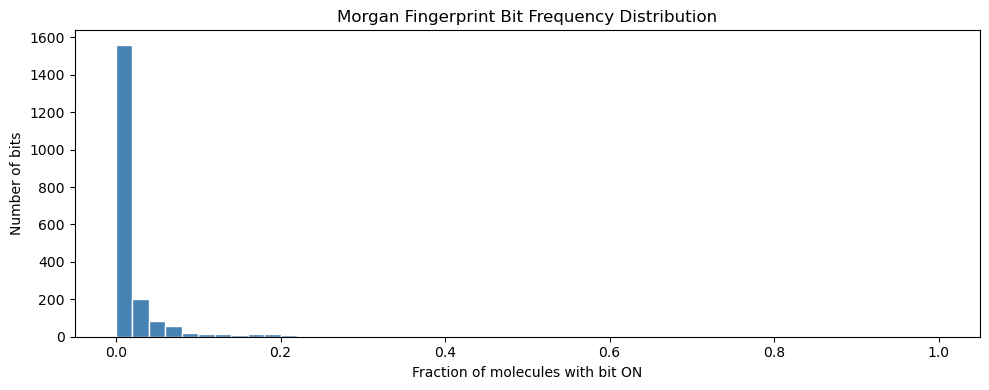

Plot saved to results/


In [4]:
bit_frequencies = X.sum(axis=0) / len(X)  # fraction of molecules with each bit ON

plt.figure(figsize=(10, 4))
plt.hist(bit_frequencies, bins=50, color='steelblue', edgecolor='white')
plt.title('Morgan Fingerprint Bit Frequency Distribution')
plt.xlabel('Fraction of molecules with bit ON')
plt.ylabel('Number of bits')
plt.tight_layout()
plt.savefig('../results/03_bit_frequency.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 5. Visualize a Sample Molecule

Let's look at one active and one inactive molecule to build intuition.

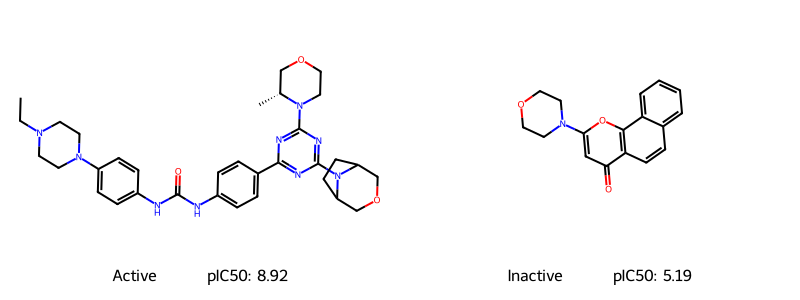

In [7]:
# Pick one active and one inactive
sample_active   = df[df['activity'] == 1].iloc[0]
sample_inactive = df[df['activity'] == 0].iloc[0]

mol_active   = Chem.MolFromSmiles(sample_active['canonical_smiles'])
mol_inactive = Chem.MolFromSmiles(sample_inactive['canonical_smiles'])

img = Draw.MolsToGridImage(
    [mol_active, mol_inactive],
    molsPerRow=2,
    subImgSize=(400, 300),
    legends=[
        f"Active — pIC50: {sample_active['pIC50']:.2f}",
        f"Inactive — pIC50: {sample_inactive['pIC50']:.2f}"
    ],
    useSVG=False,
    returnPNG=False
)

# Handle both possible return types depending on RDKit version
if hasattr(img, 'save'):
    img.save('../results/03_sample_molecules.png')
else:
    with open('../results/03_sample_molecules.png', 'wb') as f:
        f.write(img.data)

img

## 6. Save Fingerprint Matrix with Labels

In [8]:
# Build column names: bit_0, bit_1, ..., bit_2047
bit_cols = [f'bit_{i}' for i in range(N_BITS)]

df_fps = pd.DataFrame(X, columns=bit_cols)

# Attach identifiers and labels
df_fps.insert(0, 'molecule_chembl_id', df['molecule_chembl_id'].values)
df_fps.insert(1, 'pIC50',              df['pIC50'].values)
df_fps.insert(2, 'activity',           df['activity'].values)

df_fps.to_csv(OUTPUT_PATH, index=False)
print(f'Fingerprint dataset saved to {OUTPUT_PATH}')
print(f'Shape: {df_fps.shape}')  # (4354, 2051): 2048 bits + 3 metadata cols

Fingerprint dataset saved to ../data/processed/btk_fps.csv
Shape: (4354, 2051)


## Observations

### Fingerprint matrix
- Shape: **(4.354 molecules × 2.048 bits)** — each molecule is now a binary vector
- Most bits are sparse (OFF for most molecules) — expected for Morgan fingerprints
- Bits that are never activated carry no information and will be ignored by the models automatically

### Why ECFP4 (radius=2, 2048 bits)?
- **Radius 2** captures circular substructures up to 2 bonds from each atom — enough to encode rings, functional groups, and local chemical environment
- **2048 bits** is the standard size: large enough to minimize bit collisions (two different substructures mapping to the same bit), compact enough for efficient computation
- ECFP4 is the most widely validated fingerprint in QSAR literature — a reliable baseline before exploring other representations

### What the sample molecules show
- Active BTK inhibitors tend to have complex heterocyclic scaffolds — typical of kinase inhibitors
- The fingerprint captures these structural differences as different bit patterns

**Next:** `04_modeling.ipynb` — Random Forest and SVM training with cross-validation.

## Observations and Fingerprint Report

### Fingerprint matrix
- **4.354 molecules** converted to Morgan fingerprints (ECFP4)
- **0 conversion failures** — every curated SMILES was successfully fingerprinted
- Final matrix shape: **(4.354, 2.048)** — one binary vector per molecule

### Bit statistics
- **Average bit density: 3.0%** — on average, only ~3% of the 2.048 bits are "ON" per molecule.
  This sparsity is expected and typical for Morgan fingerprints: most substructures
  in a given molecule are a small subset of all possible substructures the fingerprint can encode.
- **39 bits never activated** across the entire dataset — these correspond to substructures
  that simply don't appear in any BTK inhibitor in our data. They carry no information
  and will be implicitly ignored by the models.
- **1 bit always activated** — likely corresponds to a very common structural motif
  in BTK inhibitors (e.g., an aromatic ring or basic nitrogen group), consistent with
  the kinase-inhibitor chemotype.

### Visual inspection: active vs. inactive
Comparing one highly active compound (pIC50 = 8.92) against a weakly active one (pIC50 = 5.19):

- The **active** compound has a larger, more complex scaffold — multiple nitrogen-containing
  rings (piperidine/piperazine-like) connected through a flexible urea linker. This kind of
  basic, flexible architecture is common in kinase inhibitors, as these nitrogen atoms often
  form key interactions with residues in the ATP-binding pocket.
- The **inactive** compound is simpler and more rigid — a small fused bicyclic aromatic system
  with a single secondary amine. It likely lacks the structural features needed to occupy
  the BTK binding pocket effectively.

This qualitative difference is exactly what the Morgan fingerprint encodes numerically:
specific ring systems, nitrogen placement, and connectivity patterns become distinct bit
patterns that the models will learn to associate with activity.

### Why ECFP4 (radius=2, 2048 bits) — recap
- **Radius 2** captures circular substructures up to 2 bonds from each atom — enough to
  encode rings, functional groups, and local chemical environment without becoming too
  specific (which would hurt generalization).
- **2048 bits** balances information capacity against bit collisions (different substructures
  mapping to the same bit index). It's the most widely validated configuration in QSAR literature.
- This makes ECFP4 a strong, well-established baseline before exploring alternative
  representations (e.g., physicochemical descriptors, MACCS keys, or graph-based embeddings)
  in future projects.

### Known issue (non-blocking)
`AllChem.GetMorganFingerprintAsBitVect` triggered a deprecation warning — RDKit recommends
migrating to the newer `MorganGenerator` API in future versions. Functionality is unaffected
for this project; noted here for future refactoring.

## Summary

| Item | Value |
|------|-------|
| Input molecules | 4.354 |
| Fingerprint type | Morgan (ECFP4) |
| Radius | 2 |
| Bits | 2.048 |
| Output shape | (4.354, 2.051) |
| Output file | `data/processed/btk_fps.csv` |

**Next:** `04_modeling.ipynb` — Random Forest + SVM with stratified cross-validation.